In [24]:
import scanpy as sc
import os
import pandas as pd
import matplotlib as mpl
import sys
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/amossi/Documents/code')
import FISHspace as sp
%reload_ext autoreload
%autoreload 2

mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['xtick.minor.pad'] = 2
mpl.rcParams['xtick.major.pad'] = 2
mpl.rcParams['ytick.minor.pad'] = 2
mpl.rcParams['ytick.major.pad'] = 2
mpl.rcParams['xtick.minor.width'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.minor.width'] = 2
mpl.rcParams['ytick.major.width'] = 2



In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)


In [28]:
palette = {
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F

    'preOPC-like':'#7befb2',#'#c2f970'

    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR 1': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 4': '#CA90C5',
    'WR 7': '#D873B6',
    'WR 8': '#e76d89',#'#C50F53',
    'WR 6': '#e76d89',#'#840034',
        
    
    'nIPC-like 1':'#FFF192',
    'nIPC-like 2':'#FFF192',
    'nIPC-like 3':'#FFF192',
    
    'RG-like':'#ff9470',
    'RG-nIPC-like':'#ff9470',
    
    'OPC-like 1':'#89c4f4', #bright turquoise
    'OPC-like 2':'#89c4f4', #bright turquoise

    'Endothelial':'#8c14fc',#'#d5b8ff', #mauve
    'Mural cell 1': '#8c14fc',  #electric indigo
    'Mural cell 2': '#8c14fc',  #electric indigo
    
    'FB-like 2': '#FF6EC7', #fff9de
    'FB-like 3': '#FF6EC7', #fff9de
     #'FB-like 1': '#FF6EC7', #fff9de

    'Mono 1': '#c8f7c5',#'#e6d9cb',#'#cdd1e4',#'#f4ede4',
    'Mono 2': '#FBFCFA',
    
    'TAM-BDM 1':'#e88474',#'#F5C9B0',
    'TAM-BDM 2':'#A94A54',
    
    'TAM-BDM 3':'#89c4f4',#'#95a5a6',#'#ecd9dd',
    'TAM-BDM 4':'#DC9D57',#'#A5765C',
    
    'TAM-MG':'#825e5c', #'#00b5cc' (blue),
    
    'DC': '#a6915c',
    'Oligodendrocyte':'#392e4a',
    'Astrocyte':'#038aff',
}

In [8]:
SL061 = adata[np.array([True if s.count('SL061') else False for s in adata.obs.Sample ])]

In [9]:

# Noted below the updated gene naWR (Neftel had some old gene symbols)
WR1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
WR2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
WR = np.concatenate((WR1, WR2))

WR = WR[np.isin(WR, adata.var_names.values)]

def compute_WR_score(adata):

    genes =adata.var_names
    n_genes = len(genes)
    expression = adata.X
    total_umi = adata.X.sum(axis=1)
    expression = (expression.T / total_umi).T * np.median(total_umi)
    expression = expression - np.mean(expression, axis=0)
    
    expression_order = np.argsort(adata.X.sum(axis=0))
    genes = genes[expression_order]
    expression = expression[:, expression_order]

    bin_size = n_genes // 10

    def gene_signature_score(signature_genes):
        score = np.mean(expression[:, np.isin(genes, signature_genes)], axis=1)
        control_genes = np.zeros(n_genes, dtype=bool)
        for g in signature_genes:
            ix = np.where(genes == g)[0][0]
            ix = min(ix, n_genes - bin_size)  # Make sure the last bin is complete
            random50 = np.random.choice(bin_size, size=50, replace=False)
            control_genes[random50 + ix // bin_size * bin_size] = True
        control_score = np.mean(expression[:, control_genes], axis=1)
        return score - control_score

    WR_score = gene_signature_score(WR)

    return WR_score

In [10]:
SL061.obsm['WRscore'] = compute_WR_score(SL061)


/var/folders/wt/ft7rv1yx7152d1skc4w_cvbh0000gp/T/ipykernel_21370/2621738695.py:1: ImplicitModificationWarning: Setting element `.obsm['WRscore']` of view, initializing view as actual.
  SL061.obsm['WRscore'] = compute_WR_score(SL061)


In [14]:
SL061

AnnData object with n_obs × n_vars = 902008 × 878
    obs: 'Area', 'CellID', 'Centroid', 'Polygons', 'Sample', 'X', 'Y', 'batch', 'ID', 'm-states80', 'tumour_vs_astrocyte', 'm-states'
    var: 'Accession', 'Gene'
    obsm: 'spatial', 'WRscore'

In [17]:
'''palette = {
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#049372',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F
    
    'GBL-like 1':'#c2f970',#'#c2f970'
    'GBL-like 2':'#c2f970',#'#c2f970'
    
    'preOPC-like 1':'#2ecc71',#inchworm B4FF9F
    #'preOPC-like 1':'#7befb2',#'#c2f970'

    'nIPC-like 1':'#FFF192', #atomic tangerine
    'nIPC-like 2':'#FFF192', #atomic tangerine
    'nIPC-like 3':'#FFF192', #atomic tangerine
    
    'RG-like':'#ff9470',
    
    'nIPC-RG-like':'#7dfee3',
    #'RG-nIPC-like':'#ff9470', 
    
    'OPC-like 1':'#89c4f4',
    'OPC-like 2':'#89c4f4', #bright turquoise
    
    'Astrocyte':'#049372', #jungles greeen
    'Oligodendrocyte 1':'#392e4a',#martynique
    'Oligodendrocyte 2':'#392e4a',#martynique
    

    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR 1': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 7': '#e43c96',
    'WR 8': '#c44d56',
    'WR 4': '#A40447',
    'WR 6': '#c44d56',
    
    'Endothelial 1':'#C8E683', # '#d5b8ff',  
    'Mural cell 1': '#C8E683',
    'Mural cell 2': '#C8E683',
    
    'FB-like 1': '#9f5afd',#'#ff9470',
    'FB-like 2': '#9f5afd',#'#ff9470',
    'FB-like 3': '#9f5afd',#'#ff9470',
    
    
    'Mono 1':'#9f5afd', #alabaster
    'Mono 2':'#9f5afd', #alabaster
    'TAM-BDM 1':'#e3ba8f', #wood
    'TAM-BDM 2':'#e3ba8f', #wood
    'TAM-BDM 3':'#e3ba8f', #wood
    'TAM-BDM 4':'#e3ba8f', #wood
    'TAM-MG':'#a6915c',#red orange

    'Fibroblast': '#fbe7ef',
    'FBL-like': '#FF6EC7', #fff9de
    

}'''

"palette = {\n    'AC-like 4':'#2ecc71',#inchworm B4FF9F\n    'AC-like 5':'#2ecc71',#inchworm B4FF9F\n    'AC-like 2':'#2ecc71',#inchworm B4FF9F\n    'AC-like 1':'#2ecc71',#inchworm B4FF9F\n    'AC-like 2':'#2ecc71',#inchworm B4FF9F\n    'AC-like 3':'#2ecc71',#inchworm B4FF9F\n    'AC-like 6':'#049372',#inchworm B4FF9F\n    'AC-like 7':'#2ecc71',#inchworm B4FF9F\n    \n    'GBL-like 1':'#c2f970',#'#c2f970'\n    'GBL-like 2':'#c2f970',#'#c2f970'\n    \n    'preOPC-like 1':'#2ecc71',#inchworm B4FF9F\n    #'preOPC-like 1':'#7befb2',#'#c2f970'\n\n    'nIPC-like 1':'#FFF192', #atomic tangerine\n    'nIPC-like 2':'#FFF192', #atomic tangerine\n    'nIPC-like 3':'#FFF192', #atomic tangerine\n    \n    'RG-like':'#ff9470',\n    \n    'nIPC-RG-like':'#7dfee3',\n    #'RG-nIPC-like':'#ff9470', \n    \n    'OPC-like 1':'#89c4f4',\n    'OPC-like 2':'#89c4f4', #bright turquoise\n    \n    'Astrocyte':'#049372', #jungles greeen\n    'Oligodendrocyte 1':'#392e4a',#martynique\n    'Oligodendrocyte 2':'#

In [18]:
vmin = SL061.obsm['WRscore'].min()
vmax = np.quantile(SL061.obsm['WRscore'], .98)

INFO:root:First filter, 328870 cells left


WRscore (328870, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
0.7897324 -0.11131793


INFO:root:Zoom filter, 328870 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


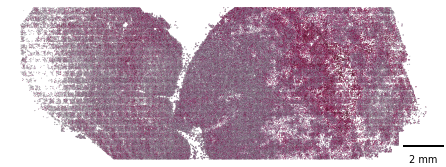

In [22]:
# Core
fig, ax = plt.subplots(1,1,figsize=(5,5))
sp.pl.plot_polygons_obsm(
    SL061,
    sample = 'SL061A',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL061.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    ax=ax,
)
plt.savefig('figures/SL061A_WR.svg', dpi=300, transparent=True)
plt.show()

INFO:root:First filter, 328870 cells left
INFO:root:Zoom filter, 328870 cells left


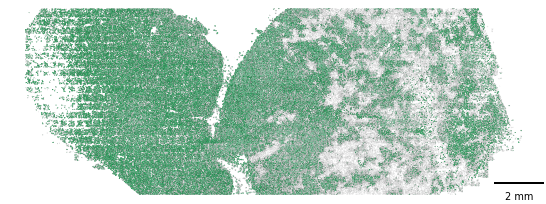

INFO:root:First filter, 328870 cells left
INFO:root:Zoom filter, 328870 cells left


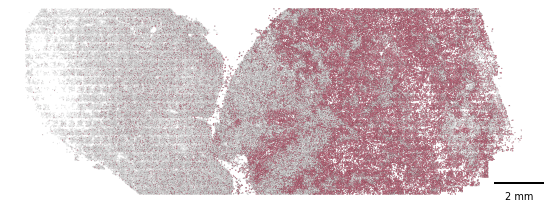

INFO:root:First filter, 328870 cells left
INFO:root:Zoom filter, 328870 cells left


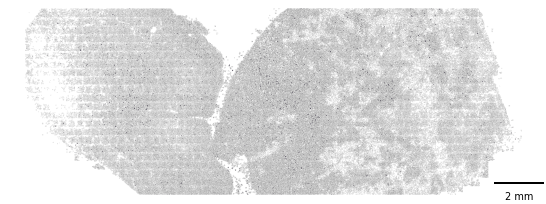

INFO:root:First filter, 328870 cells left
INFO:root:Zoom filter, 328870 cells left


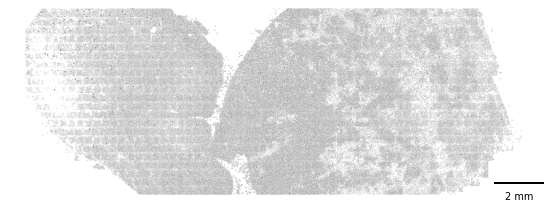

INFO:root:First filter, 328870 cells left
INFO:root:Zoom filter, 328870 cells left


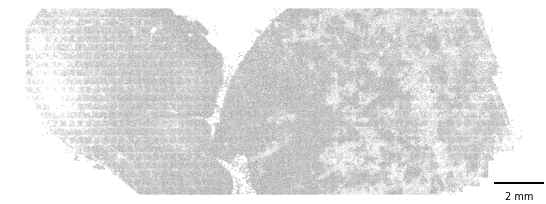

In [29]:
# High
d = {
    'Glia': ['AC-like 1','AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 3','AC-like 7','preOPC-like'],
    'WR':['WR 6','WR 8'],
    'Oligo':['Oligodendrocyte'], 
    'Astro':['Astrocyte'],
    'Mono':['Mono 1', 'Mono 2'], 
}

for cs in d:
    
    fig, ax = plt.subplots(1,1,figsize=(6,6))
    sp.pl.plot_polygons(
        SL061,
        sample = 'SL061A',
        cluster_key='m-states',
        clusters = d[cs],
        grey_clusters=SL061.obs['m-states'].cat.categories.tolist(),
        alpha=.9,
        alpha_gray=.25,
        palette= palette,
        ax=ax,
    )

    plt.savefig(f'figures/SL061A_{cs}.svg', dpi=300, transparent=True)
    plt.show()

INFO:root:First filter, 367612 cells left


WRscore (367612, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
0.61550593 -0.11131793


INFO:root:Zoom filter, 367612 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


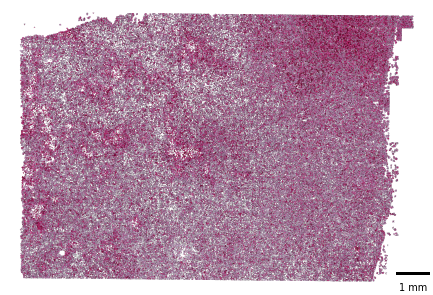

In [30]:
# High
fig, ax = plt.subplots(1,1,figsize=(5,5))
sp.pl.plot_polygons_obsm(
    SL061,
    sample = 'SL061B',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL061.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    ax=ax,
)
plt.savefig('figures/SL061B_WR.svg', dpi=300, transparent=True)
plt.show()

INFO:root:First filter, 367612 cells left
INFO:root:Zoom filter, 367612 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


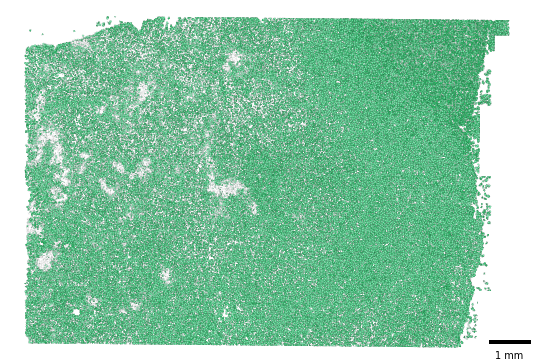

INFO:root:First filter, 367612 cells left
INFO:root:Zoom filter, 367612 cells left


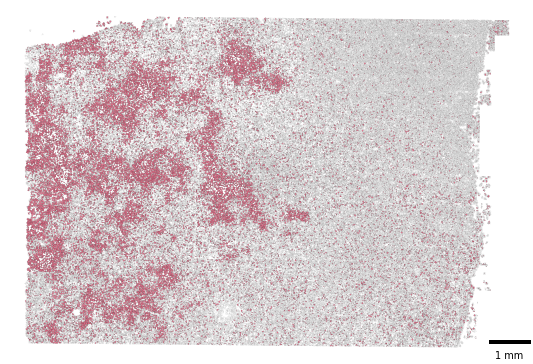

INFO:root:First filter, 367612 cells left
INFO:root:Zoom filter, 367612 cells left


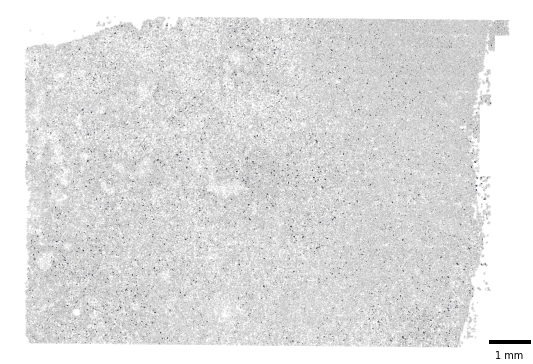

INFO:root:First filter, 367612 cells left
INFO:root:Zoom filter, 367612 cells left


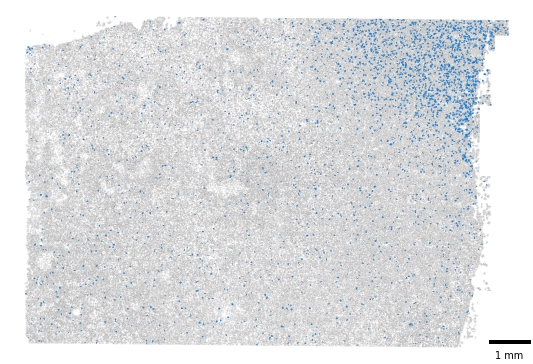

INFO:root:First filter, 367612 cells left
INFO:root:Zoom filter, 367612 cells left


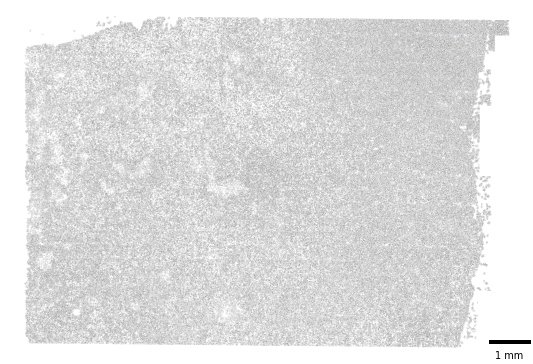

In [31]:
# High
d = {
    'Glia': ['AC-like 1','AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 3','AC-like 7','preOPC-like'],
    'WR':['WR 6','WR 8'],
    'Oligo':['Oligodendrocyte'], 
    'Astro':['Astrocyte'],
    'Mono':['Mono 1', 'Mono 2'], 
}
# High

for cs in d:
    
    fig, ax = plt.subplots(1,1,figsize=(6,6))
    sp.pl.plot_polygons(
        SL061,
        sample = 'SL061B',
        cluster_key='m-states',
        clusters = d[cs],
        grey_clusters=SL061.obs['m-states'].cat.categories.tolist(),
        alpha_gray=.25,
        alpha=.9,
        palette= palette,
        ax=ax,
    )

    plt.savefig(f'figures/SL061B_{cs}.svg', dpi=300, transparent=True)
    plt.show()

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left


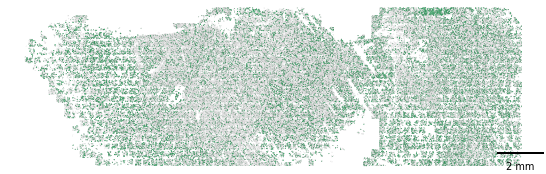

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left


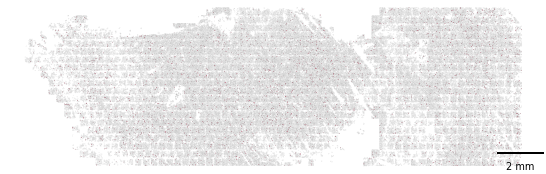

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left


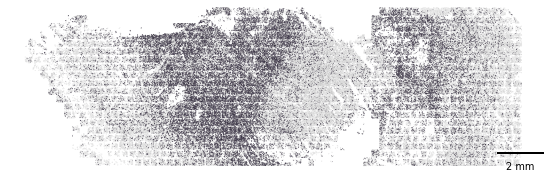

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left


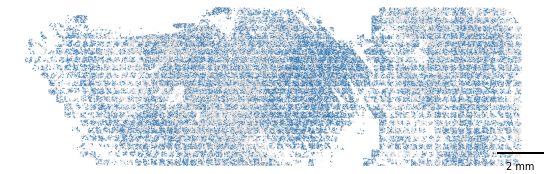

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


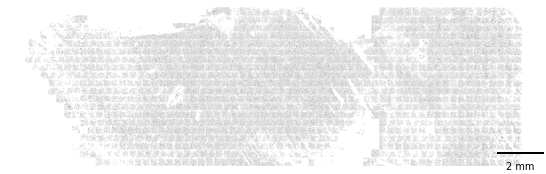

In [32]:
# High
d = {
    'Glia': ['AC-like 1','AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 3','AC-like 7','preOPC-like'],
    'WR':['WR 6','WR 8'],
    'Oligo':['Oligodendrocyte'], 
    'Astro':['Astrocyte'],
    'Mono':['Mono 1', 'Mono 2'], 
}
for cs in d:
    
    fig, ax = plt.subplots(1,1,figsize=(6,6))
    sp.pl.plot_polygons(
        SL061,
        sample = 'SL061C',
        cluster_key='m-states',
        clusters = d[cs],
        grey_clusters=SL061.obs['m-states'].cat.categories.tolist(),
        alpha_gray=.25,
        alpha=.9,
        palette= palette,
        ax=ax,
    )

    plt.savefig(f'figures/SL061C_{cs}.svg', dpi=300, transparent=True)
    plt.show()

INFO:root:First filter, 207545 cells left
INFO:root:Zoom filter, 207545 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


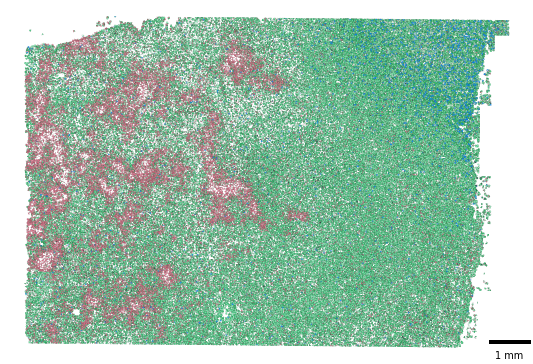

In [34]:
# High
fig, ax = plt.subplots(1,1,figsize=(6,6))
sp.pl.plot_polygons(
    SL061,
    sample = 'SL061B',
    cluster_key='m-states',
    clusters = [
        'AC-like 1','AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 3','AC-like 7',
        'preOPC-like', 'Oligodendrocyte', 'WR 6','WR 8', 'Astrocyte','Mono 1', 'Mono 2',
                ],
    palette= palette,
    ax=ax,
)
plt.savefig('figures/SL061B.svg', dpi=300, transparent=True)
plt.show()

INFO:root:First filter, 138436 cells left


WRscore (138436, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
0.54943097 -0.11131793


INFO:root:Zoom filter, 138436 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


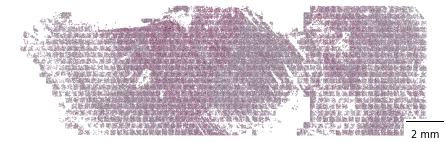

In [35]:
# Low
fig, ax = plt.subplots(1,1,figsize=(5,5))
sp.pl.plot_polygons_obsm(
    SL061,
    sample = 'SL061C',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL061.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    ax=ax
)
plt.savefig('figures/SL061C_WR.svg', dpi=300, transparent=True)
plt.show()

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left


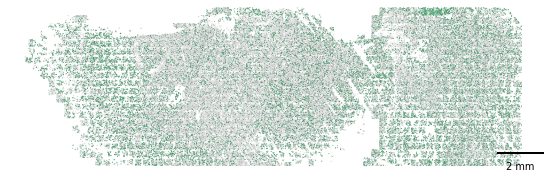

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left


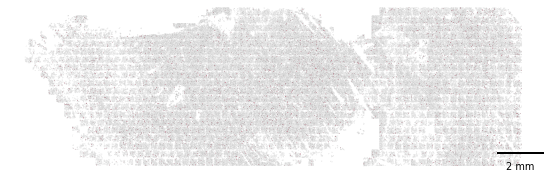

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left


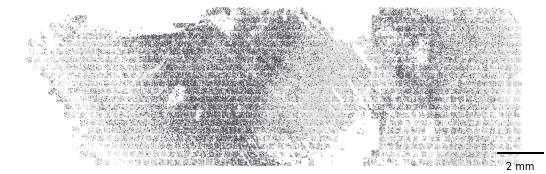

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left


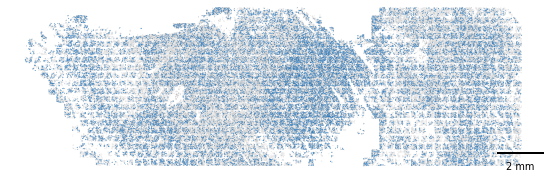

INFO:root:First filter, 138436 cells left
INFO:root:Zoom filter, 138436 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


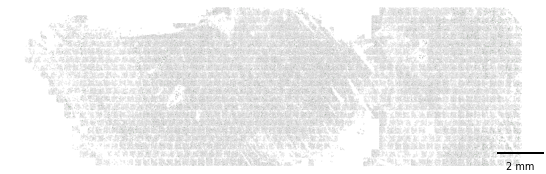

In [36]:
# High
d = {
    'Glia': ['AC-like 1','AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 3','AC-like 7','preOPC-like'],
    'WR':['WR 6','WR 8'],
    'Oligo':['Oligodendrocyte'], 
    'Astro':['Astrocyte'],
    'Mono':['Mono 1', 'Mono 2'], 
}
for cs in d:
    
    fig, ax = plt.subplots(1,1,figsize=(6,6))
    sp.pl.plot_polygons(
        SL061,
        sample = 'SL061C',
        cluster_key='m-states',
        clusters = d[cs],
        grey_clusters=SL061.obs['m-states'].cat.categories.tolist(),
        palette= palette,
        ax=ax,
    )

    plt.savefig(f'figures/SL061C_{cs}.svg', dpi=300, transparent=True)
    plt.show()

INFO:root:First filter, 96120 cells left
INFO:root:Zoom filter, 96120 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


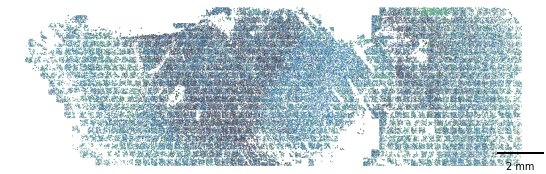

In [37]:
# High
fig, ax = plt.subplots(1,1,figsize=(6,6))
sp.pl.plot_polygons(
    SL061,
    sample = 'SL061C',
    cluster_key='m-states',
    clusters = [
        'AC-like 1','AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 3','AC-like 7',
        'preOPC-like', 'Oligodendrocyte', 'WR 6','WR 8', 'Astrocyte','Mono 1', 'Mono 2',
                ],
    palette= palette,
    ax=ax,
)
plt.savefig('figures/SL061C.svg', dpi=300, transparent=True)
plt.show()